In [1]:
# Jalankan sel ini sekali untuk memasang pustaka yang dibutuhkan (boleh dilewati jika sudah terpasang).
# Jika setelah instalasi masih muncul ModuleNotFoundError, restart kernel lalu jalankan ulang dari atas.
%pip install -q geopandas sentinelhub folium seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\OKAN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import os, math, time, getpass, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.raster_layers import ImageOverlay
from shapely.geometry import Point
from IPython.display import display, Markdown

from sentinelhub import (SHConfig, SentinelHubRequest, DataCollection, BBox, CRS,
                         MimeType, bbox_to_dimensions)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             cohen_kappa_score, f1_score)

# ----------------- KONFIGURASI (SESUAIKAN) -----------------
DATA_DIR    = "."                                  # folder berisi shapefile
TANGGAL_MULAI, TANGGAL_AKHIR = "2025-01-01", "2025-12-31"   # periode citra
MAX_CLOUD   = 30                                   # maks. % awan per scene
HANYA_SENTINEL_2A = False                          # True: buang citra Sentinel-2B/2C
SEED        = 42                                   # agar hasil dapat direproduksi
CSV_DATASET = "dataset_sentinel2_jatim.csv"
ULANGI_EKSTRAKSI = False                           # True: paksa ambil ulang dari Copernicus
# ------------------------------------------------------------

# id : nama kelas, berkas shapefile, target sampel, warna peta
KELAS = {
    1: dict(nama="Sawah",                   file="sawah",       n=50, warna="#FFD92F"),
    2: dict(nama="Bangunan",                file="bangunan",    n=50, warna="#E41A1C"),
    3: dict(nama="Mangrove",                file="mangrove",    n=50, warna="#8E44AD"),
    4: dict(nama="Lahan Hijau",             file="lahan_hijau", n=50, warna="#2E7D32"),
    5: dict(nama="Perairan Terbuka (Laut)", file="lautan",      n=35, warna="#0D47A1"),
    6: dict(nama="Danau",                   file="danau",       n=50, warna="#4FC3F7"),
}
NAMA_KELAS  = [v["nama"] for v in KELAS.values()]
WARNA_KELAS = {v["nama"]: v["warna"] for v in KELAS.values()}
print("Jumlah kelas:", len(KELAS), "->", NAMA_KELAS)

Jumlah kelas: 6 -> ['Sawah', 'Bangunan', 'Mangrove', 'Lahan Hijau', 'Perairan Terbuka (Laut)', 'Danau']


In [3]:
def baca_shp(path):
    g = gpd.read_file(path)
    g = g.set_crs(4326) if g.crs is None else g.to_crs(4326)
    g = g[g.geometry.notnull() & ~g.geometry.is_empty].copy()
    g["geometry"] = g.geometry.apply(lambda x: x if x.is_valid else x.buffer(0))
    return g[["geometry"]].reset_index(drop=True)

def cari_shp(nama):
    """Mencari file <nama>.shp di DATA_DIR dan seluruh subfoldernya (spasi dan underscore dianggap sama)."""
    target = nama.lower().replace(" ", "_")
    for root, _, files in os.walk(DATA_DIR):
        for f in files:
            if f.lower().endswith(".shp") and f[:-4].lower().replace(" ", "_") == target:
                return os.path.join(root, f)
    raise FileNotFoundError(f"File {nama}.shp tidak ditemukan di '{os.path.abspath(DATA_DIR)}' maupun subfoldernya.")

jalur_shp = {k: cari_shp(v["file"]) for k, v in KELAS.items()}
for k, p in jalur_shp.items():
    print(f"{KELAS[k]['nama']:<26} -> {p}")
poligon = {k: baca_shp(p) for k, p in jalur_shp.items()}

ringkas = []
for k, v in KELAS.items():
    g = poligon[k]
    luas_ha = g.to_crs(32749).area.sum() / 10_000      # UTM 49S, untuk luas dalam hektar
    b = g.total_bounds
    ringkas.append({"ID": k, "Kelas": v["nama"], "Jumlah poligon": len(g),
                    "Total luas (ha)": round(luas_ha, 1), "Target sampel": v["n"],
                    "BT min": round(b[0], 3), "LS min": round(b[1], 3),
                    "BT maks": round(b[2], 3), "LS maks": round(b[3], 3)})
display(pd.DataFrame(ringkas).set_index("ID"))

Sawah                      -> .\sawah\sawah.shp
Bangunan                   -> .\bangunan\bangunan.shp
Mangrove                   -> .\mangrove\mangrove.shp
Lahan Hijau                -> .\hutan_atau_lahan_hijau\lahan_hijau.shp
Perairan Terbuka (Laut)    -> .\lautan\lautan.shp
Danau                      -> .\danau\danau.shp


,Kelas,Jumlah poligon,Total luas (ha),Target sampel,BT min,LS min,BT maks,LS maks
ID,,,,,,,,
1,Sawah,51,6.1,50,112.601,-7.159,112.629,-7.149
2,Bangunan,62,44.7,50,112.605,-7.148,112.615,-7.139
3,Mangrove,50,1207.9,50,112.801,-7.633,112.952,-7.244
4,Lahan Hijau,50,195087.1,50,111.363,-8.767,114.584,-7.260
5,Perairan Terbuka (Laut),35,19284156.4,35,110.716,-9.574,117.276,-4.258
6,Danau,50,754.0,50,111.020,-8.615,114.430,-6.946


In [4]:
rng = np.random.default_rng(SEED)

def titik_acak(poly, rng, maks=300):
    minx, miny, maxx, maxy = poly.bounds
    for _ in range(maks):
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if poly.contains(p):
            return p
    return poly.representative_point()

def ambil_sampel(gdf, n, rng):
    polys = list(gdf.geometry)
    urutan = rng.permutation(len(polys))
    hasil = []
    if len(polys) >= n:
        for i in urutan[:n]:
            hasil.append((polys[i].representative_point(), int(i)))
    else:
        for i in urutan:
            hasil.append((polys[i].representative_point(), int(i)))
        while len(hasil) < n:
            i = int(rng.integers(len(polys)))
            hasil.append((titik_acak(polys[i], rng), i))
    return hasil

baris = []
for k, v in KELAS.items():
    for p, pid in ambil_sampel(poligon[k], v["n"], rng):
        baris.append({"kelas_id": k, "kelas": v["nama"], "poligon_id": pid, "lon": p.x, "lat": p.y})
df_titik = pd.DataFrame(baris).reset_index(drop=True)
df_titik.index.name = "idx"
print("Total titik sampel:", len(df_titik))
display(df_titik["kelas"].value_counts().reindex(NAMA_KELAS).to_frame("jumlah titik"))

Total titik sampel: 285


,jumlah titik
kelas,
Sawah,50
Bangunan,50
Mangrove,50
Lahan Hijau,50
Perairan Terbuka (Laut),35
Danau,50


In [5]:
# ---------- Daftar fitur ----------
BAND_ASLI = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
INDEKS    = ["NDVI", "NDWI", "MNDWI", "NDBI", "NDRE", "EVI", "SAVI", "BSI"]
FITUR_SEMUA = BAND_ASLI + INDEKS

# ---------- Koneksi ke Copernicus Data Space Ecosystem ----------
_cache = {}
def buat_config():
    """Membuat konfigurasi Sentinel Hub untuk CDSE (kredensial diminta sekali saja)."""
    if "cfg" not in _cache:
        cfg = SHConfig()
        cfg.sh_client_id = os.environ.get("CDSE_CLIENT_ID") or input("Masukkan Client ID  : ").strip()
        cfg.sh_client_secret = os.environ.get("CDSE_CLIENT_SECRET") or getpass.getpass("Masukkan Client Secret: ").strip()
        cfg.sh_base_url = "https://sh.dataspace.copernicus.eu"
        cfg.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
        _cache["cfg"] = cfg
        try:
            _cache["data"] = DataCollection.SENTINEL2_L2A.define_from("s2l2a_cdse", service_url=cfg.sh_base_url)
        except Exception:   # sudah pernah didefinisikan (sel dijalankan ulang)
            _cache["data"] = [c for c in DataCollection.get_available_collections() if c.name == "s2l2a_cdse"][0]
    return _cache["cfg"], _cache["data"]

# ---------- Evalscript: masking awan (SCL) + komposit median 10 band ----------
EVALSCRIPT_TEMPLATE = """//VERSION=3
const HANYA_2A = __HANYA_2A__;
function setup() {
  return {
    input: [{ bands: ["B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12","SCL","dataMask"] }],
    output: { bands: 10, sampleType: "FLOAT32" },
    mosaicking: "ORBIT"
  };
}
function median(a) {
  a.sort(function(x, y) { return x - y; });
  var m = Math.floor(a.length / 2);
  return a.length % 2 ? a[m] : (a[m - 1] + a[m]) / 2;
}
function evaluatePixel(samples, scenes) {
  var nama = ["B02","B03","B04","B05","B06","B07","B08","B8A","B11","B12"];
  var nilai = nama.map(function() { return []; });
  for (var i = 0; i < samples.length; i++) {
    var s = samples[i];
    if (s.dataMask === 0) continue;
    var c = s.SCL;
    if (c === 3 || c === 8 || c === 9 || c === 10 || c === 11) continue;
    if (HANYA_2A) {
      var pid = scenes.orbits[i].tiles[0].productId;
      if (pid.indexOf("S2A") !== 0) continue;
    }
    for (var k = 0; k < nama.length; k++) nilai[k].push(s[nama[k]]);
  }
  if (nilai[0].length === 0) return nama.map(function() { return NaN; });
  return nilai.map(median);
}
"""
EVALSCRIPT = EVALSCRIPT_TEMPLATE.replace("__HANYA_2A__", "true" if HANYA_SENTINEL_2A else "false")

def ambil_median(bbox, ukuran):
    """Mengunduh komposit median 10 band untuk bbox dan ukuran (lebar, tinggi) piksel tertentu.
    Hasil: array (tinggi, lebar, 10)."""
    cfg, data = buat_config()
    req = SentinelHubRequest(
        evalscript=EVALSCRIPT,
        input_data=[SentinelHubRequest.input_data(
            data_collection=data, time_interval=(TANGGAL_MULAI, TANGGAL_AKHIR),
            maxcc=MAX_CLOUD / 100)],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox, size=ukuran, config=cfg)
    return np.asarray(req.get_data()[0], dtype=np.float32)

def tambah_indeks(d):
    """Menghitung 8 indeks spektral dari DataFrame berisi kolom band B2..B12 (reflektansi 0-1)."""
    d = d.copy()
    e = 1e-9                                           # menghindari pembagian dengan nol
    nd = lambda a, b: (a - b) / (a + b + e)
    d["NDVI"]  = nd(d["B8"], d["B4"])
    d["NDWI"]  = nd(d["B3"], d["B8"])
    d["MNDWI"] = nd(d["B3"], d["B11"])
    d["NDBI"]  = nd(d["B11"], d["B8"])
    d["NDRE"]  = nd(d["B8"], d["B5"])
    d["EVI"]   = 2.5 * (d["B8"] - d["B4"]) / (d["B8"] + 6 * d["B4"] - 7.5 * d["B2"] + 1)
    d["SAVI"]  = 1.5 * (d["B8"] - d["B4"]) / (d["B8"] + d["B4"] + 0.5)
    d["BSI"]   = (((d["B11"] + d["B4"]) - (d["B8"] + d["B2"])) /
                  ((d["B11"] + d["B4"]) + (d["B8"] + d["B2"]) + e))
    return d

print("Fitur yang dihasilkan (%d):" % len(FITUR_SEMUA), FITUR_SEMUA)

Fitur yang dihasilkan (18): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDBI', 'NDRE', 'EVI', 'SAVI', 'BSI']


In [6]:
def ekstrak_titik(df_titik):
    baris = []
    n = len(df_titik)
    for k, (i, r) in enumerate(df_titik.iterrows(), start=1):
        dlat = 15 / 111320.0                                         # setengah kotak 30 m
        dlon = 15 / (111320.0 * math.cos(math.radians(r.lat)))
        bbox = BBox([r.lon - dlon, r.lat - dlat, r.lon + dlon, r.lat + dlat], crs=CRS.WGS84)
        nilai = [np.nan] * len(BAND_ASLI)
        for percobaan in range(3):
            try:
                arr = ambil_median(bbox, (3, 3))
                nilai = list(arr[1, 1, :])                           # piksel tengah
                break
            except Exception as e:
                if percobaan == 2:
                    print(f"\nGagal titik {i}: {str(e)[:120]}")
                time.sleep(3)
        baris.append(nilai)
        print(f"\rTitik {k}/{n}", end="")
    print()
    return pd.DataFrame(baris, columns=BAND_ASLI, index=df_titik.index)

if os.path.exists(CSV_DATASET) and not ULANGI_EKSTRAKSI:
    df = pd.read_csv(CSV_DATASET)
    print("Dataset dimuat dari", CSV_DATASET)
else:
    df_band = ekstrak_titik(df_titik)
    df = tambah_indeks(df_titik.join(df_band)).reset_index(drop=True)
    df.to_csv(CSV_DATASET, index=False)
    print("Dataset diekstraksi dari Copernicus dan disimpan ke", CSV_DATASET)

df = df.replace([np.inf, -np.inf], np.nan)
sebelum = len(df)
df = df.dropna(subset=FITUR_SEMUA).reset_index(drop=True)      # buang titik tanpa data bersih
print(f"Sampel awal: {sebelum} | sampel valid: {len(df)} | dibuang (nodata/awan): {sebelum-len(df)}")
display(df.head())

Dataset dimuat dari dataset_sentinel2_jatim.csv
Sampel awal: 285 | sampel valid: 285 | dibuang (nodata/awan): 0


,kelas_id,kelas,poligon_id,lon,lat,B2,B3,B4,B5,B6,...,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
0,1,Sawah,27,112.602069,-7.154831,0.04830,0.0750,0.0678,0.1435,0.22440,...,0.21150,0.12750,0.584559,-0.550360,-0.476440,-0.100191,0.286247,0.366036,0.346321,-0.047083
1,1,Sawah,7,112.626293,-7.150999,0.05230,0.0811,0.0832,0.1425,0.26415,...,0.25070,0.14625,0.536490,-0.545531,-0.511151,-0.047673,0.318671,0.348219,0.336321,0.008761
2,1,Sawah,46,112.604086,-7.158440,0.05000,0.0725,0.0588,0.1049,0.19460,...,0.19050,0.10730,0.579399,-0.505626,-0.448669,-0.073669,0.355849,0.337894,0.311698,-0.041338
3,1,Sawah,38,112.602510,-7.156883,0.05865,0.0825,0.0861,0.1291,0.21690,...,0.21220,0.12935,0.505599,-0.521323,-0.440109,-0.105396,0.340148,0.328809,0.311387,-0.036421
4,1,Sawah,50,112.604521,-7.158059,0.04805,0.0713,0.0582,0.1073,0.18440,...,0.15925,0.08340,0.563718,-0.490532,-0.381479,-0.134158,0.320671,0.314007,0.294210,-0.082683


Jumlah kelas : 6
Jumlah data  : 285


,jumlah sampel
kelas,
Sawah,50
Bangunan,50
Mangrove,50
Lahan Hijau,50
Perairan Terbuka (Laut),35
Danau,50


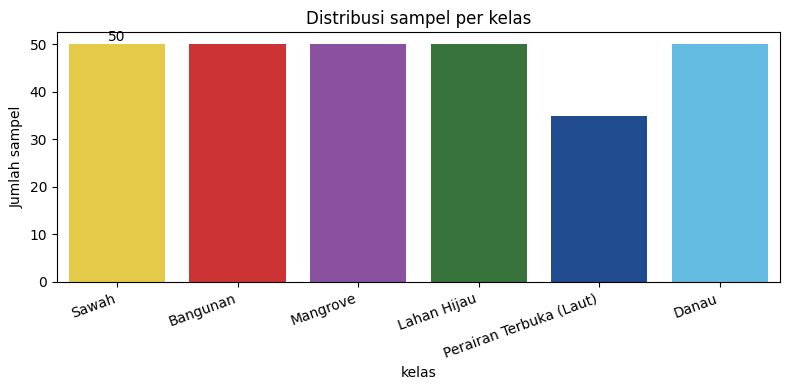

In [7]:
jml = df["kelas"].value_counts().reindex(NAMA_KELAS)
print("Jumlah kelas :", df["kelas"].nunique())
print("Jumlah data  :", len(df))
display(jml.to_frame("jumlah sampel"))

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=jml.index, y=jml.values, palette=[WARNA_KELAS[k] for k in jml.index])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=20, ha="right"); plt.ylabel("Jumlah sampel"); plt.title("Distribusi sampel per kelas")
plt.tight_layout(); plt.show()

In [8]:
display(df[FITUR_SEMUA].describe().T.round(4))
print("\nRata-rata fitur per kelas:")
display(df.groupby("kelas")[FITUR_SEMUA].mean().reindex(NAMA_KELAS).round(3))

,count,mean,std,min,25%,50%,75%,max
B2,285.0,0.0571,0.0280,0.0211,0.0381,0.0498,0.0670,0.1912
B3,285.0,0.0756,0.0317,0.0154,0.0536,0.0742,0.0922,0.2008
B4,285.0,0.0680,0.0450,0.0099,0.0328,0.0555,0.0911,0.2448
B5,285.0,0.1082,0.0464,0.0095,0.0824,0.1129,0.1414,0.2155
B6,285.0,0.1740,0.0906,0.0044,0.1191,0.1848,0.2418,0.3574
B7,285.0,0.1973,0.1077,0.0055,0.1322,0.2002,0.2745,0.4564
B8,285.0,0.1958,0.1128,0.0048,0.0983,0.2086,0.2776,0.5312
B8A,285.0,0.2110,0.1184,0.0035,0.1434,0.2144,0.3004,0.4775
B11,285.0,0.1546,0.0904,0.0092,0.0832,0.1602,0.2294,0.3457
B12,285.0,0.1081,0.0827,0.0082,0.0426,0.0846,0.1659,0.3046



Rata-rata fitur per kelas:


,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,NDVI,NDWI,MNDWI,NDBI,NDRE,EVI,SAVI,BSI
kelas,,,,,,,,,,,,,,,,,,
Sawah,0.052,0.080,0.073,0.130,0.234,0.269,0.268,0.293,0.207,0.117,0.568,-0.534,-0.435,-0.131,0.345,0.369,0.345,-0.071
Bangunan,0.102,0.119,0.140,0.158,0.174,0.182,0.184,0.199,0.258,0.239,0.142,-0.217,-0.369,0.166,0.074,0.089,0.081,0.164
Mangrove,0.040,0.068,0.040,0.108,0.247,0.290,0.293,0.308,0.115,0.050,0.742,-0.605,-0.237,-0.434,0.446,0.507,0.449,-0.362
Lahan Hijau,0.055,0.075,0.070,0.121,0.214,0.248,0.251,0.266,0.205,0.147,0.554,-0.525,-0.472,-0.089,0.332,0.354,0.324,-0.057
Perairan Terbuka (Laut),0.043,0.031,0.024,0.025,0.023,0.023,0.021,0.022,0.021,0.019,-0.066,0.213,0.207,0.006,-0.105,-0.007,-0.007,-0.193
Danau,0.047,0.067,0.048,0.082,0.107,0.120,0.105,0.121,0.082,0.050,0.179,-0.027,0.044,-0.081,-0.044,0.117,0.105,-0.059


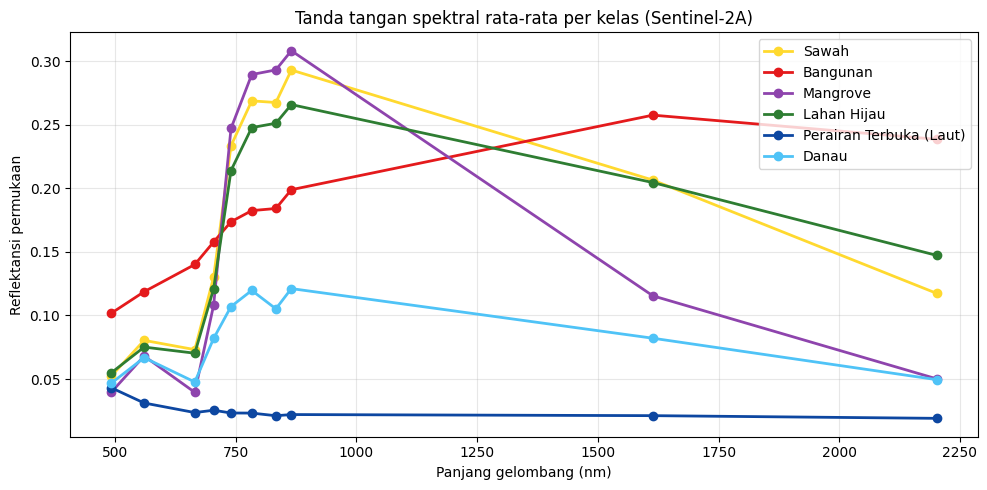

In [9]:
panjang_gelombang = [492, 560, 665, 704, 740, 783, 833, 865, 1614, 2202]
rata = df.groupby("kelas")[BAND_ASLI].mean().reindex(NAMA_KELAS)

plt.figure(figsize=(10, 5))
for k in NAMA_KELAS:
    plt.plot(panjang_gelombang, rata.loc[k].values, marker="o", lw=2, label=k, color=WARNA_KELAS[k])
plt.xlabel("Panjang gelombang (nm)"); plt.ylabel("Reflektansi permukaan")
plt.title("Tanda tangan spektral rata-rata per kelas (Sentinel-2A)")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

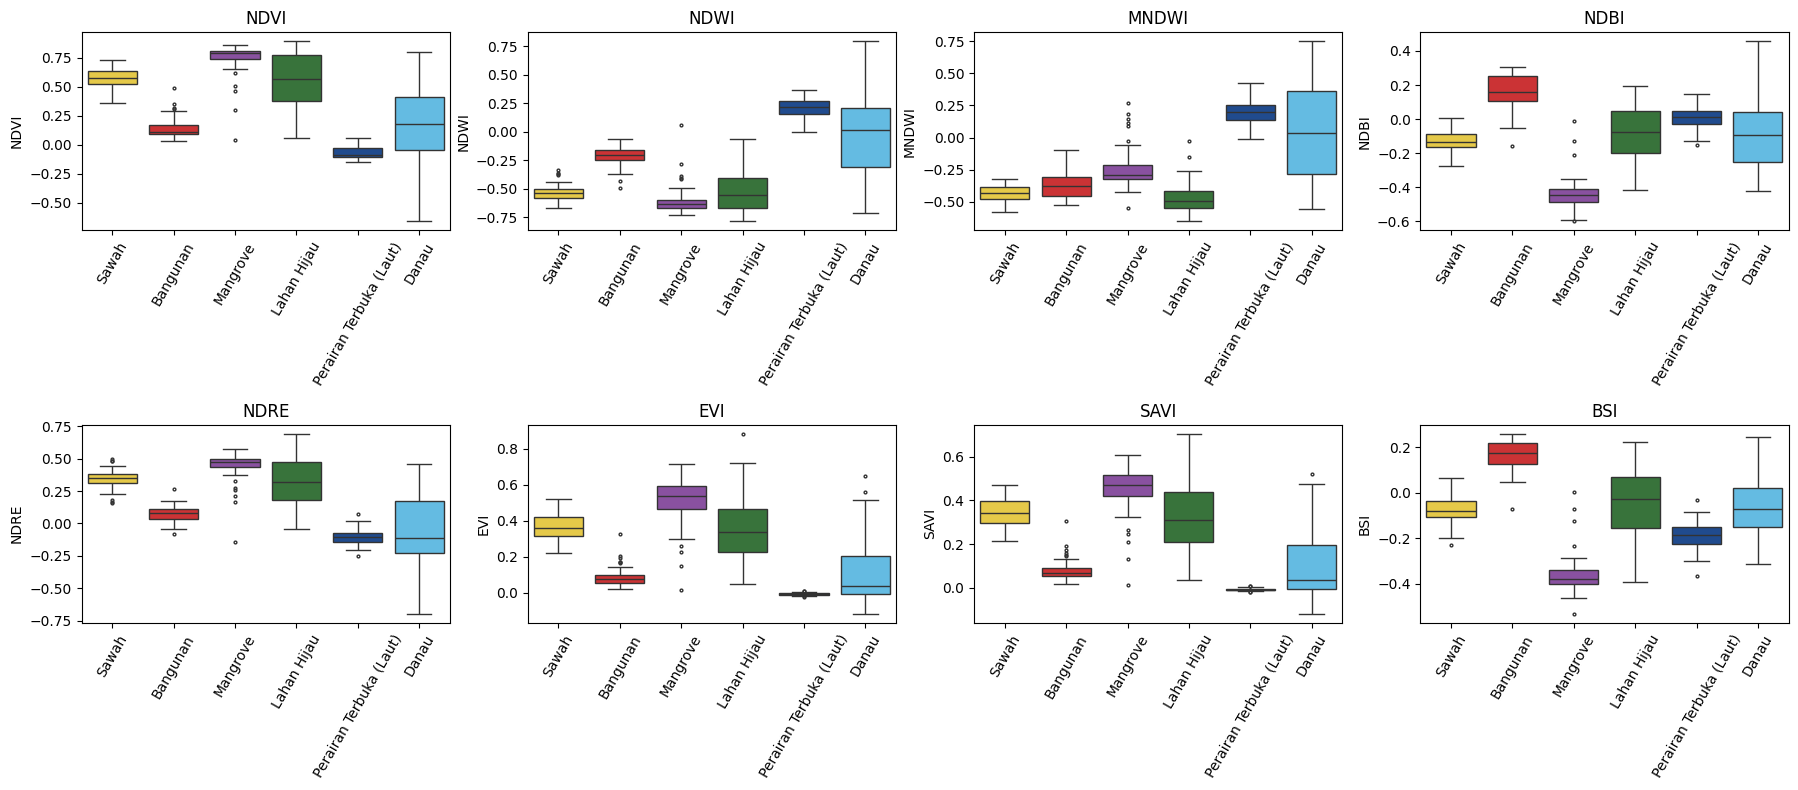

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, f in zip(axes.ravel(), INDEKS):
    sns.boxplot(data=df, x="kelas", y=f, order=NAMA_KELAS, palette=WARNA_KELAS, ax=ax, fliersize=2)
    ax.set_title(f); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

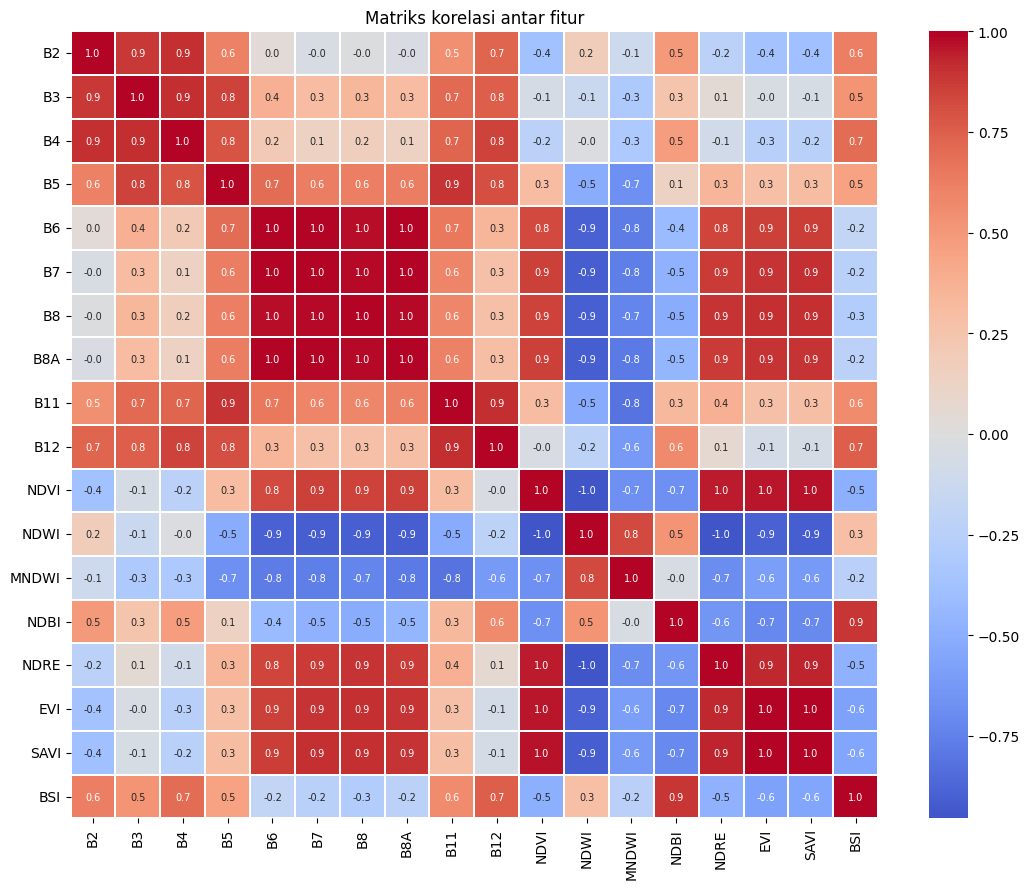

In [11]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[FITUR_SEMUA].corr(), cmap="coolwarm", center=0, annot=True, fmt=".1f",
            annot_kws={"size": 7}, linewidths=.3)
plt.title("Matriks korelasi antar fitur"); plt.tight_layout(); plt.show()

In [12]:
UKURAN_TEST = 0.20
X = df[FITUR_SEMUA]
y = df["kelas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=UKURAN_TEST, stratify=y, random_state=SEED)

tabel_split = pd.DataFrame({
    "Total":    y.value_counts(),
    "Training": y_train.value_counts(),
    "Testing":  y_test.value_counts(),
}).reindex(NAMA_KELAS)
tabel_split.loc["TOTAL"] = tabel_split.sum()
print(f"Jumlah kelas        : {y.nunique()}")
print(f"Jumlah data training: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Jumlah data testing : {len(X_test)} ({len(X_test)/len(X):.0%})")
display(tabel_split.astype(int))

Jumlah kelas        : 6
Jumlah data training: 228 (80%)
Jumlah data testing : 57 (20%)


,Total,Training,Testing
kelas,,,
Sawah,50,40,10
Bangunan,50,40,10
Mangrove,50,40,10
Lahan Hijau,50,40,10
Perairan Terbuka (Laut),35,28,7
Danau,50,40,10
TOTAL,285,228,57


,Akurasi,Kappa,F1 macro
Dataset,,,
Training,1.0000,1.0000,1.0000
Testing,0.7895,0.7472,0.7843



--- Laporan Klasifikasi Data Testing (Baseline KNN k=5) ---
                         precision    recall  f1-score   support

                  Sawah       0.67      1.00      0.80        10
               Bangunan       0.80      0.80      0.80        10
               Mangrove       1.00      0.80      0.89        10
            Lahan Hijau       0.67      0.40      0.50        10
Perairan Terbuka (Laut)       0.78      1.00      0.88         7
                  Danau       0.89      0.80      0.84        10

               accuracy                           0.79        57
              macro avg       0.80      0.80      0.78        57
           weighted avg       0.80      0.79      0.78        57



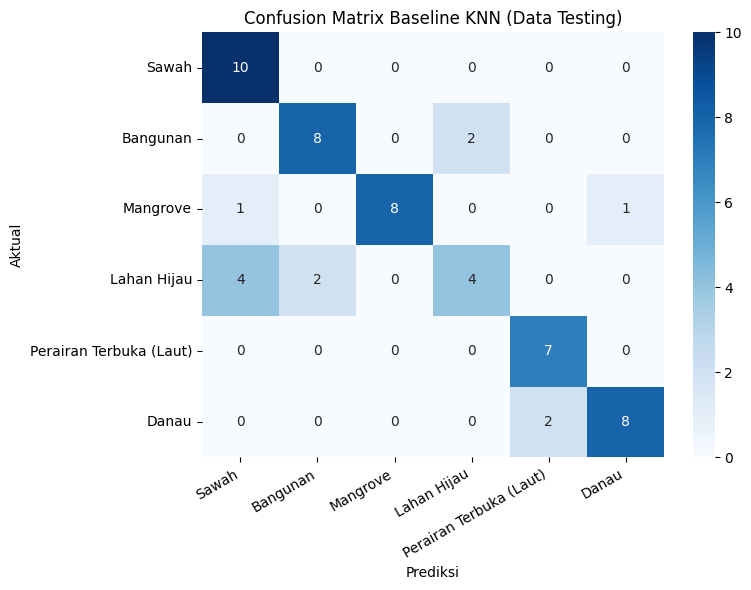

In [13]:
# Model baseline KNN (k=5, weights='distance') dengan StandardScaler
model_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance"))
])
model_baseline.fit(X_train, y_train)

pred_train = model_baseline.predict(X_train)
pred_test  = model_baseline.predict(X_test)

def metrik(y_true, y_pred):
    return {
        "Akurasi": accuracy_score(y_true, y_pred),
        "Kappa":   cohen_kappa_score(y_true, y_pred),
        "F1 macro": f1_score(y_true, y_pred, average="macro"),
    }

ringkas_eval = pd.DataFrame([
    {"Dataset": "Training", **metrik(y_train, pred_train)},
    {"Dataset": "Testing",  **metrik(y_test,  pred_test)},
]).set_index("Dataset")
display(ringkas_eval.round(4))

print("\n--- Laporan Klasifikasi Data Testing (Baseline KNN k=5) ---")
print(classification_report(y_test, pred_test, labels=NAMA_KELAS, zero_division=0))

cm = confusion_matrix(y_test, pred_test, labels=NAMA_KELAS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS)
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title("Confusion Matrix Baseline KNN (Data Testing)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [14]:
hasil_rasio = []
for ts in [0.10, 0.20, 0.30, 0.40]:
    skor = []
    for r in range(10):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=ts, stratify=y, random_state=SEED + r)
        m = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance"))
        ]).fit(X_tr, y_tr)
        skor.append(accuracy_score(y_te, m.predict(X_te)))
    hasil_rasio.append({
        "Rasio train:test": f"{int((1-ts)*100)}:{int(ts*100)}",
        "Ukuran test": ts,
        "Akurasi rata-rata": np.mean(skor),
        "Std": np.std(skor),
    })
tab_rasio = pd.DataFrame(hasil_rasio)
display(tab_rasio.round(4))

,Rasio train:test,Ukuran test,Akurasi rata-rata,Std
0,90:10,0.1,0.8310,0.0544
1,80:20,0.2,0.8298,0.0400
2,70:30,0.3,0.8419,0.0203
3,60:40,0.4,0.8377,0.0329


In [15]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

skenario_fitur = {
    "A. 4 band 10 m (B2,B3,B4,B8)":            ["B2", "B3", "B4", "B8"],
    "B. 10 band Sentinel-2A":                  BAND_ASLI,
    "C. 8 indeks spektral":                    INDEKS,
    "D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)": ["NDVI", "MNDWI", "NDBI", "BSI"],
    "E. Band + indeks (18 fitur)":             FITUR_SEMUA,
}
hasil_fitur = []
for nama, cols in skenario_fitur.items():
    pip = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance"))
    ])
    s = cross_val_score(pip, df[cols], y, cv=cv, scoring="accuracy")
    f = cross_val_score(pip, df[cols], y, cv=cv, scoring="f1_macro")
    hasil_fitur.append({"Skenario": nama, "Jumlah fitur": len(cols),
                        "Akurasi CV": s.mean(), "Std": s.std(), "F1 macro CV": f.mean()})
tab_fitur = pd.DataFrame(hasil_fitur).sort_values("Akurasi CV", ascending=False).reset_index(drop=True)
display(tab_fitur.round(4))

FITUR_FINAL_NAMA = tab_fitur.loc[0, "Skenario"]
FITUR_FINAL = skenario_fitur[FITUR_FINAL_NAMA]
print("\nSkenario fitur terbaik:", FITUR_FINAL_NAMA, f"({len(FITUR_FINAL)} fitur)")

,Skenario,Jumlah fitur,Akurasi CV,Std,F1 macro CV
0,E. Band + indeks (18 fitur),18,0.8274,0.0426,0.8226
1,B. 10 band Sentinel-2A,10,0.8239,0.0444,0.8238
2,C. 8 indeks spektral,8,0.7842,0.0411,0.7806
3,"A. 4 band 10 m (B2,B3,B4,B8)",4,0.7656,0.0441,0.7661
4,"D. Indeks pilihan (NDVI,MNDWI,NDBI,BSI)",4,0.7649,0.0494,0.7663



Skenario fitur terbaik: E. Band + indeks (18 fitur) (18 fitur)


,k,weights,metric,Akurasi CV,Std
0,5,distance,euclidean,0.8274,0.0426
1,5,uniform,euclidean,0.8267,0.0446
2,5,distance,manhattan,0.8242,0.0438
3,5,uniform,manhattan,0.8218,0.0435
4,3,distance,euclidean,0.8211,0.0418
5,7,distance,manhattan,0.8207,0.0404
6,3,distance,manhattan,0.8193,0.0429
7,3,uniform,euclidean,0.8193,0.0410
8,3,uniform,manhattan,0.8189,0.0440
9,7,distance,euclidean,0.8168,0.0424


Hyperparameter terbaik: k=5, weights='distance', metric='euclidean' | Akurasi CV: 0.8274


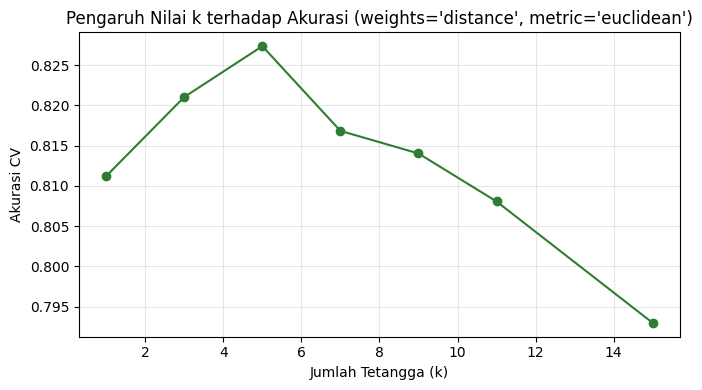

In [16]:
param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}
pip_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])
grid = GridSearchCV(pip_grid, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(df[FITUR_FINAL], y)

tab_knn = pd.DataFrame(grid.cv_results_)[["param_knn__n_neighbors", "param_knn__weights", "param_knn__metric", "mean_test_score", "std_test_score"]]
tab_knn = tab_knn.rename(columns={
    "param_knn__n_neighbors": "k",
    "param_knn__weights": "weights",
    "param_knn__metric": "metric",
    "mean_test_score": "Akurasi CV",
    "std_test_score": "Std"
}).sort_values("Akurasi CV", ascending=False).reset_index(drop=True)
display(tab_knn.head(10).round(4))

BEST_K       = grid.best_params_["knn__n_neighbors"]
BEST_WEIGHTS = grid.best_params_["knn__weights"]
BEST_METRIC  = grid.best_params_["knn__metric"]
print(f"Hyperparameter terbaik: k={BEST_K}, weights='{BEST_WEIGHTS}', metric='{BEST_METRIC}' | Akurasi CV: {grid.best_score_:.4f}")

# Visualisasi pengaruh k terhadap akurasi untuk bobot dan metrik terbaik
res_df = pd.DataFrame(grid.cv_results_)
sub_res = res_df[(res_df["param_knn__weights"] == BEST_WEIGHTS) & 
                 (res_df["param_knn__metric"] == BEST_METRIC)].sort_values("param_knn__n_neighbors")

plt.figure(figsize=(7, 4))
plt.plot(sub_res["param_knn__n_neighbors"].astype(int), sub_res["mean_test_score"], marker="o", color="#2E7D32")
plt.xlabel("Jumlah Tetangga (k)"); plt.ylabel("Akurasi CV"); plt.grid(alpha=0.3)
plt.title(f"Pengaruh Nilai k terhadap Akurasi (weights='{BEST_WEIGHTS}', metric='{BEST_METRIC}')")
plt.tight_layout(); plt.show()

Akurasi testing model final KNN : 0.7895
Kappa                           : 0.7472
F1 macro                        : 0.7843

                         precision    recall  f1-score   support

                  Sawah       0.67      1.00      0.80        10
               Bangunan       0.80      0.80      0.80        10
               Mangrove       1.00      0.80      0.89        10
            Lahan Hijau       0.67      0.40      0.50        10
Perairan Terbuka (Laut)       0.78      1.00      0.88         7
                  Danau       0.89      0.80      0.84        10

               accuracy                           0.79        57
              macro avg       0.80      0.80      0.78        57
           weighted avg       0.80      0.79      0.78        57



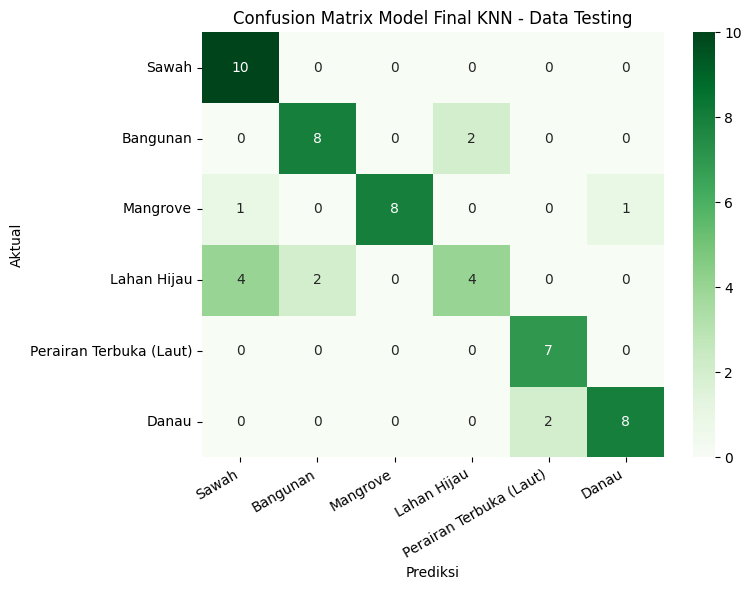

In [17]:
model_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=BEST_K, weights=BEST_WEIGHTS, metric=BEST_METRIC))
]).fit(X_train[FITUR_FINAL], y_train)

pred_final = model_final.predict(X_test[FITUR_FINAL])

AKURASI_FINAL = accuracy_score(y_test, pred_final)
KAPPA_FINAL   = cohen_kappa_score(y_test, pred_final)
F1_FINAL      = f1_score(y_test, pred_final, average="macro")

print(f"Akurasi testing model final KNN : {AKURASI_FINAL:.4f}")
print(f"Kappa                           : {KAPPA_FINAL:.4f}")
print(f"F1 macro                        : {F1_FINAL:.4f}\n")
print(classification_report(y_test, pred_final, labels=NAMA_KELAS, zero_division=0))

cm = confusion_matrix(y_test, pred_final, labels=NAMA_KELAS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=NAMA_KELAS, yticklabels=NAMA_KELAS)
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title("Confusion Matrix Model Final KNN - Data Testing")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

In [18]:
import os
os.environ["CDSE_CLIENT_ID"] = "sh-186caf9f-89ee-47a7-8777-ea3c802a1c55"
os.environ["CDSE_CLIENT_SECRET"] = "UzXK59XL3TLS9LyKyfGAHyJIvgckTZFsBiU9eA64P3x8EWxwEBAB67jxJjIO0pbzg0lrwegqp5UwYIeLhdR05u"

JATIM       = [111.0, -8.85, 114.65, -6.75]   # [barat, selatan, timur, utara] - seluruh Jawa Timur
AOI         = JATIM                           # ganti dengan BBOX_SURABAYA jika ingin area lebih kecil
SKALA_PETA  = 120                             # resolusi piksel (meter). 60 m = cepat (~1,5 juta piksel)
TILE_PX     = 500                             # ukuran ubin (piksel) per permintaan
ULANGI_PETA = True                            # True: paksa lengkapi ubin yang kosong/ulang
FILE_PETA   = "label_peta.npz"

from sentinelhub.download.sentinelhub_client import SentinelHubDownloadClient
# Reset cache sesi agar token autentikasi diperbarui secara segar
SentinelHubDownloadClient._CACHED_SESSIONS.clear()
if "_cache" in globals():
    _cache.clear()

# Latih ulang model final dengan seluruh data berlabel
model_peta = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=BEST_K, weights=BEST_WEIGHTS, metric=BEST_METRIC))
]).fit(df[FITUR_FINAL], df["kelas"])

def hex_ke_rgb(h):
    h = h.lstrip("#"); return [int(h[i:i+2], 16) for i in (0, 2, 4)]

def klasifikasi_aoi(aoi, skala, tile_px, model, fitur):
    """Mengklasifikasi AOI per ubin dengan Smart Resume dan pelaporan galat detail."""
    barat, selatan, timur, utara = aoi
    dx = skala / 111320.0                                  # meter -> derajat
    W = int(math.ceil((timur - barat) / dx))
    H = int(math.ceil((utara - selatan) / dx))
    n_tile = math.ceil(H / tile_px) * math.ceil(W / tile_px)
    print(f"Raster {W} x {H} piksel ({W*H:,} piksel), dibagi menjadi {n_tile} ubin")

    kode = {nama: i for i, nama in enumerate(NAMA_KELAS)}
    
    # Cek apakah sudah ada hasil sebagian sebelumnya untuk dilanjutkan
    label = np.full((H, W), -1, dtype=np.int8)
    if os.path.exists(FILE_PETA):
        try:
            z_lama = np.load(FILE_PETA, allow_pickle=True)
            if z_lama["label"].shape == (H, W):
                label = z_lama["label"].copy()
                terisi = np.sum(label != -1)
                print(f"Melanjutkan raster yang sudah ada ({terisi / (H*W):.1%} piksel sudah terisi)")
        except Exception:
            pass

    n, gagal = 0, []
    for r0 in range(0, H, tile_px):
        for c0 in range(0, W, tile_px):
            r1, c1 = min(r0 + tile_px, H), min(c0 + tile_px, W)
            n += 1

            # Jika ubin ini sudah terisi > 50%, lewati
            sub = label[r0:r1, c0:c1]
            if np.mean(sub != -1) > 0.5:
                print(f"\rUbin {n}/{n_tile} (sudah ada, dilewati)               ", end="")
                continue

            bbox = BBox([barat + c0*dx, utara - r1*dx, barat + c1*dx, utara - r0*dx], crs=CRS.WGS84)
            arr = None
            for percobaan in range(3):
                try:
                    arr = ambil_median(bbox, (c1 - c0, r1 - r0))
                    break
                except Exception as e:
                    # Ambil rincian respon dari server Copernicus
                    msg = str(e)
                    if hasattr(e, "request_exception") and hasattr(e.request_exception, "response"):
                        resp = e.request_exception.response
                        msg += f" | Respon Copernicus [{resp.status_code}]: {resp.text}"
                    elif hasattr(e, "response"):
                        resp = e.response
                        msg += f" | Respon Copernicus: {getattr(resp, 'text', '')}"
                    
                    if percobaan == 2:
                        gagal.append((r0, c0, msg))
                        print(f"\n[Galat Ubin {n}]: {msg[:250]}")
                    time.sleep(10)
                    
            print(f"\rUbin {n}/{n_tile}                                     ", end="")
            if arr is None:
                continue

            h, w = arr.shape[:2]
            d = tambah_indeks(pd.DataFrame(arr.reshape(-1, len(BAND_ASLI)), columns=BAND_ASLI))
            d = d.replace([np.inf, -np.inf], np.nan)
            valid = d[FITUR_SEMUA].notna().all(axis=1).values
            if valid.any():
                pred = model.predict(d.loc[valid, fitur])
                kk = np.full(h * w, -1, dtype=np.int8)
                kk[valid] = [kode[p] for p in pred]
                label[r0:r0+h, c0:c0+w] = kk.reshape(h, w)
            
            # Simpan progres parsial ke disk agar aman jika terputus
            batas_tmp = [[utara - H*dx, barat], [utara, barat + W*dx]]
            np.savez_compressed(FILE_PETA, label=label, batas=np.array(batas_tmp), aoi=np.array(AOI),
                                skala=SKALA_PETA, fitur=np.array(FITUR_FINAL))

            # Jeda 2 detik antar-ubin agar tidak memicu rate limit
            time.sleep(2)

    print()
    if gagal:
        print(f"PERINGATAN: {len(gagal)} ubin gagal diunduh.\nContoh galat:\n{gagal[0][2]}")
    batas = [[utara - H*dx, barat], [utara, barat + W*dx]]  # [[selatan, barat], [utara, timur]]
    return label, batas

# Jalankan klasifikasi dan lengkapi ubin yang tersisa
label_peta, batas_peta = klasifikasi_aoi(AOI, SKALA_PETA, TILE_PX, model_peta, FITUR_FINAL)
np.savez_compressed(FILE_PETA, label=label_peta, batas=np.array(batas_peta), aoi=np.array(AOI),
                    skala=SKALA_PETA, fitur=np.array(FITUR_FINAL))
print("Ukuran raster hasil:", label_peta.shape)


Raster 3386 x 1949 piksel (6,599,314 piksel), dibagi menjadi 28 ubin


Melanjutkan raster yang sudah ada (100.0% piksel sudah terisi)
Ubin 28/28 (sudah ada, dilewati)               
Ukuran raster hasil: (1949, 3386)


In [19]:
# Ubah kode kelas -> gambar RGBA (piksel tanpa data/awan dibuat transparan)
H, W = label_peta.shape
rgba = np.zeros((H, W, 4), dtype=np.uint8)
for idx, nama in enumerate(NAMA_KELAS):
    rgba[label_peta == idx] = hex_ke_rgb(WARNA_KELAS[nama]) + [255]

# Statistik luas hasil klasifikasi pada AOI
lat_tengah = (AOI[1] + AOI[3]) / 2
luas_piksel_ha = (SKALA_PETA * SKALA_PETA * math.cos(math.radians(lat_tengah))) / 10_000
jumlah = np.bincount(label_peta[label_peta >= 0].astype(int), minlength=len(NAMA_KELAS))
tab_luas = pd.DataFrame({"Jumlah piksel": jumlah}, index=NAMA_KELAS)
tab_luas["Luas (ha)"] = (tab_luas["Jumlah piksel"] * luas_piksel_ha).round(1)
tab_luas["Persentase (%)"] = (100 * tab_luas["Jumlah piksel"] / max(tab_luas["Jumlah piksel"].sum(), 1)).round(2)
print(f"Piksel tanpa data: {(label_peta < 0).sum():,} dari {label_peta.size:,}")
display(tab_luas)

Piksel tanpa data: 351 dari 6,599,314


,Jumlah piksel,Luas (ha),Persentase (%)
Sawah,2027059,2891958.2,30.72
Bangunan,120594,172048.7,1.83
Mangrove,137889,196723.0,2.09
Lahan Hijau,1373407,1959408.0,20.81
Perairan Terbuka (Laut),2582267,3684060.7,39.13
Danau,357747,510389.4,5.42


Peta disimpan: hasil_klasifikasi_knn.html (dapat ditanam di web statis lewat <iframe>)



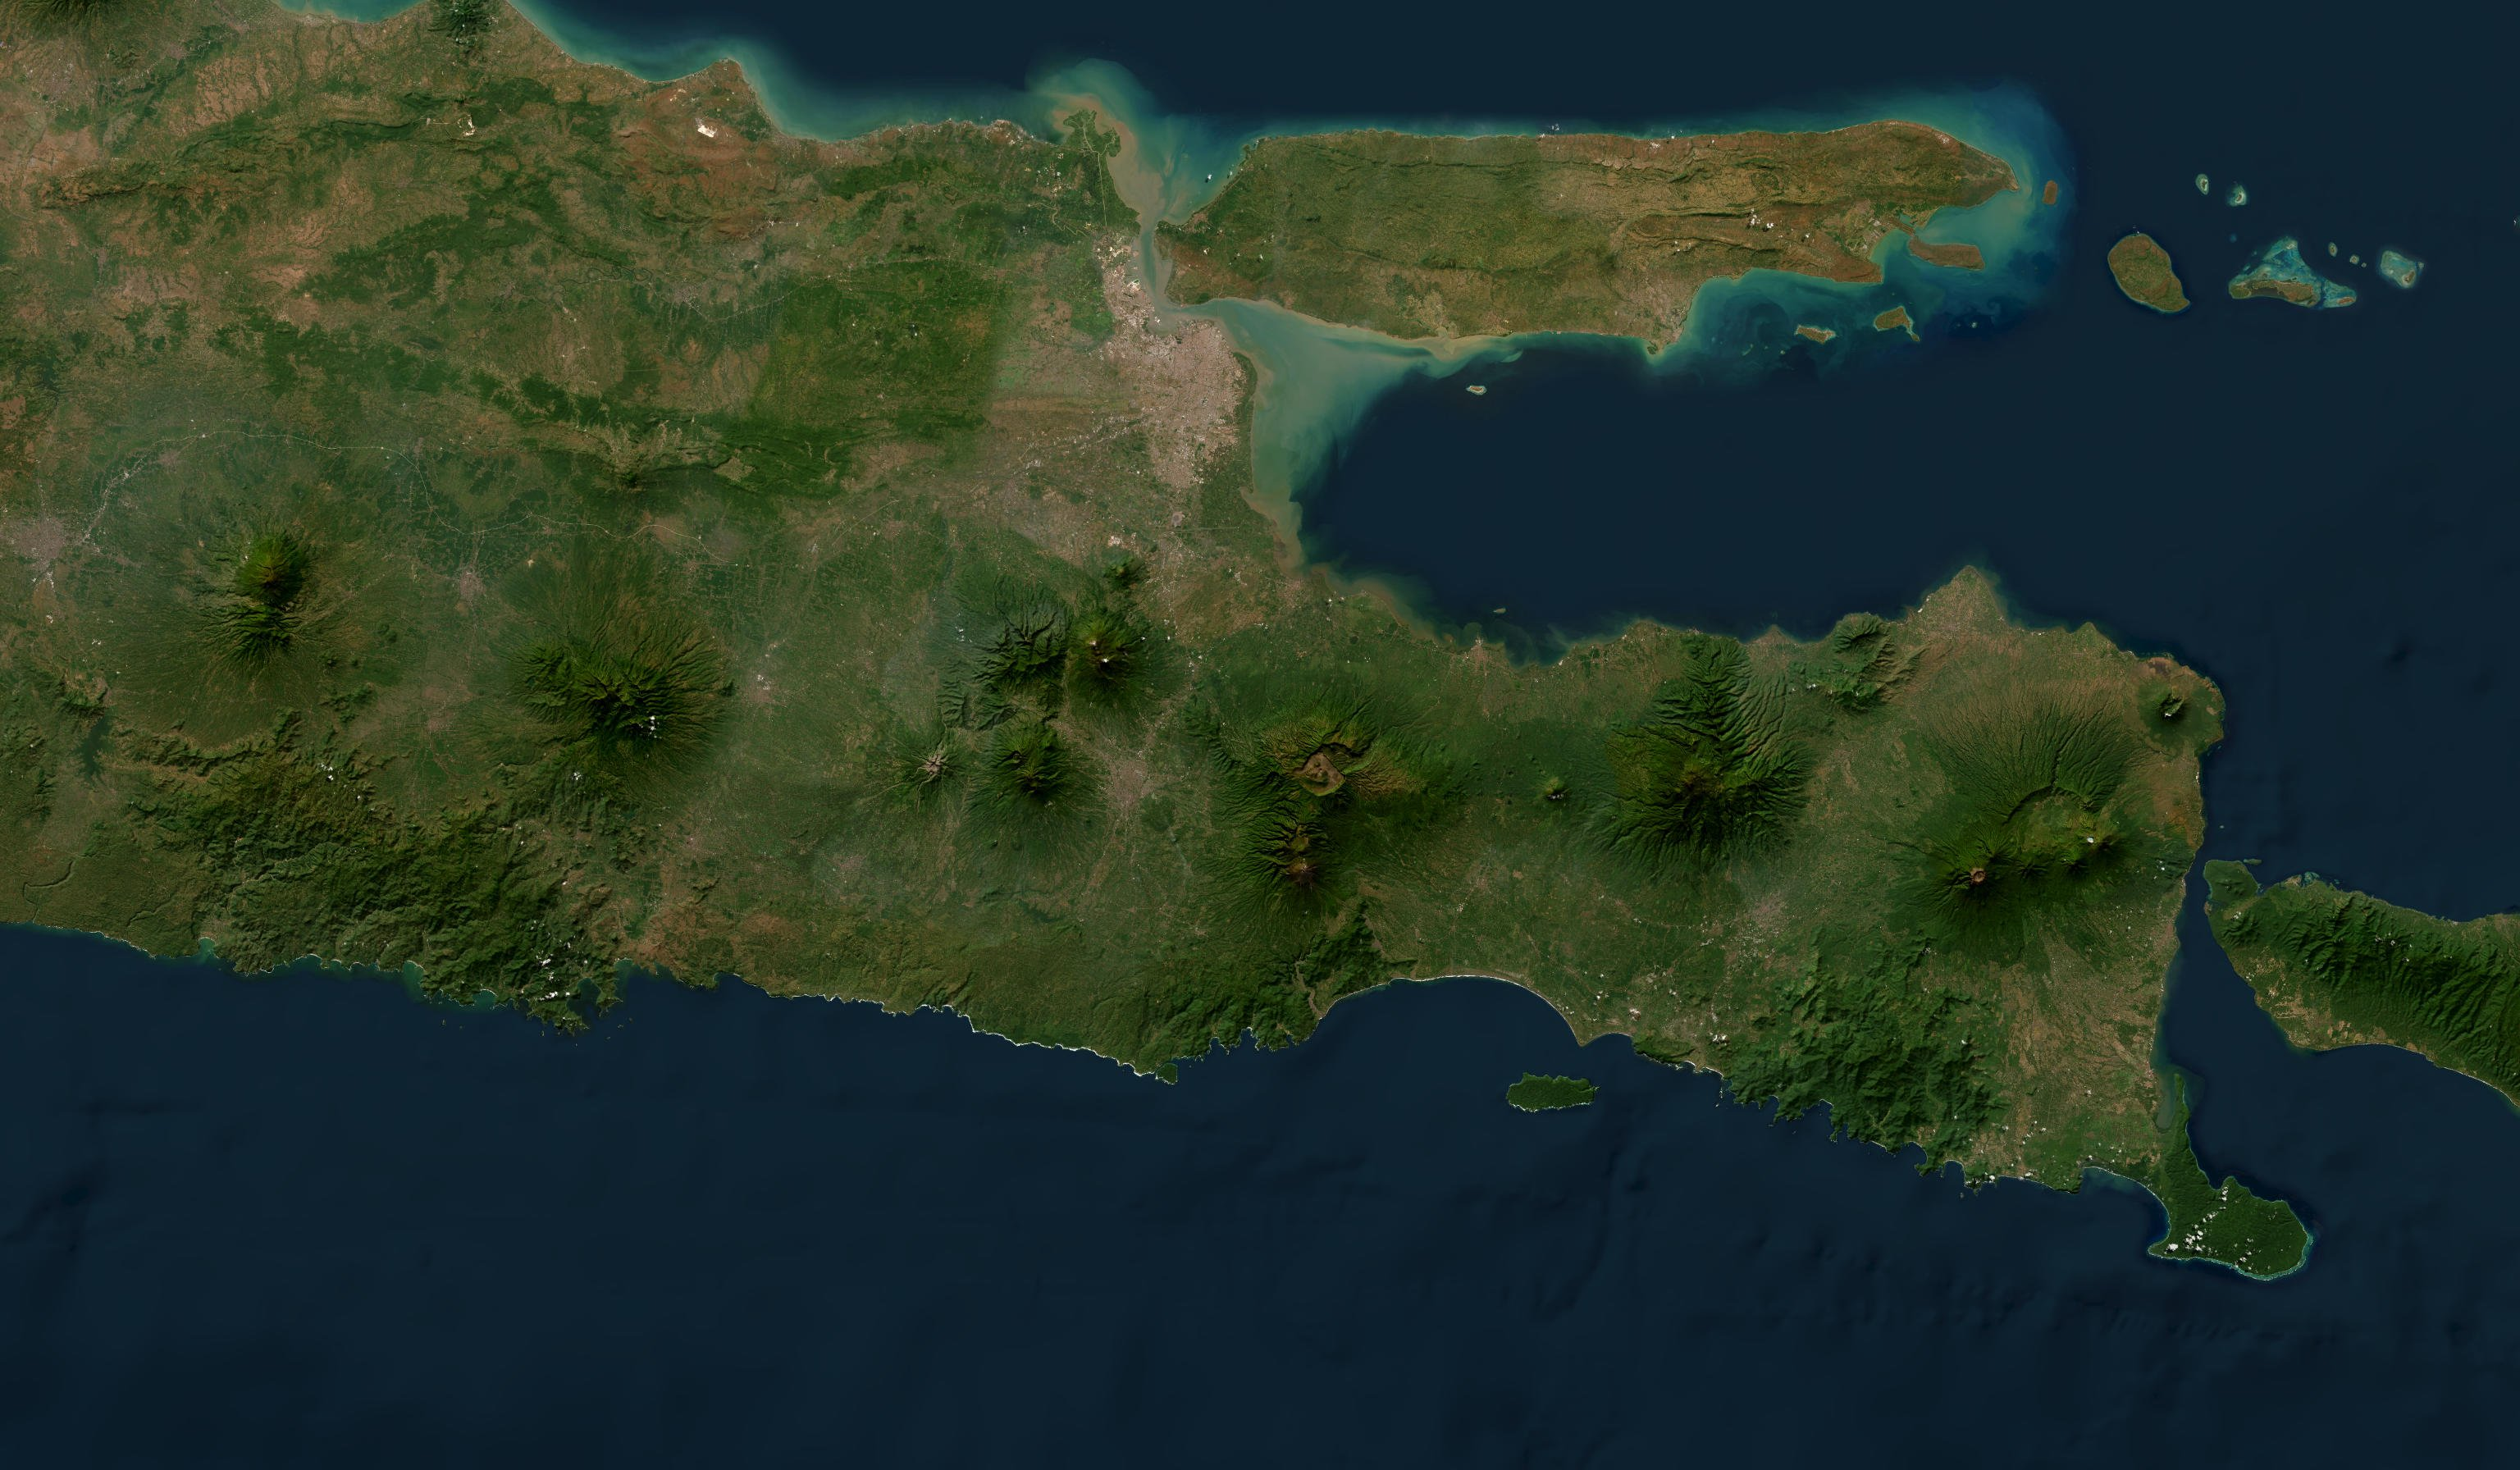
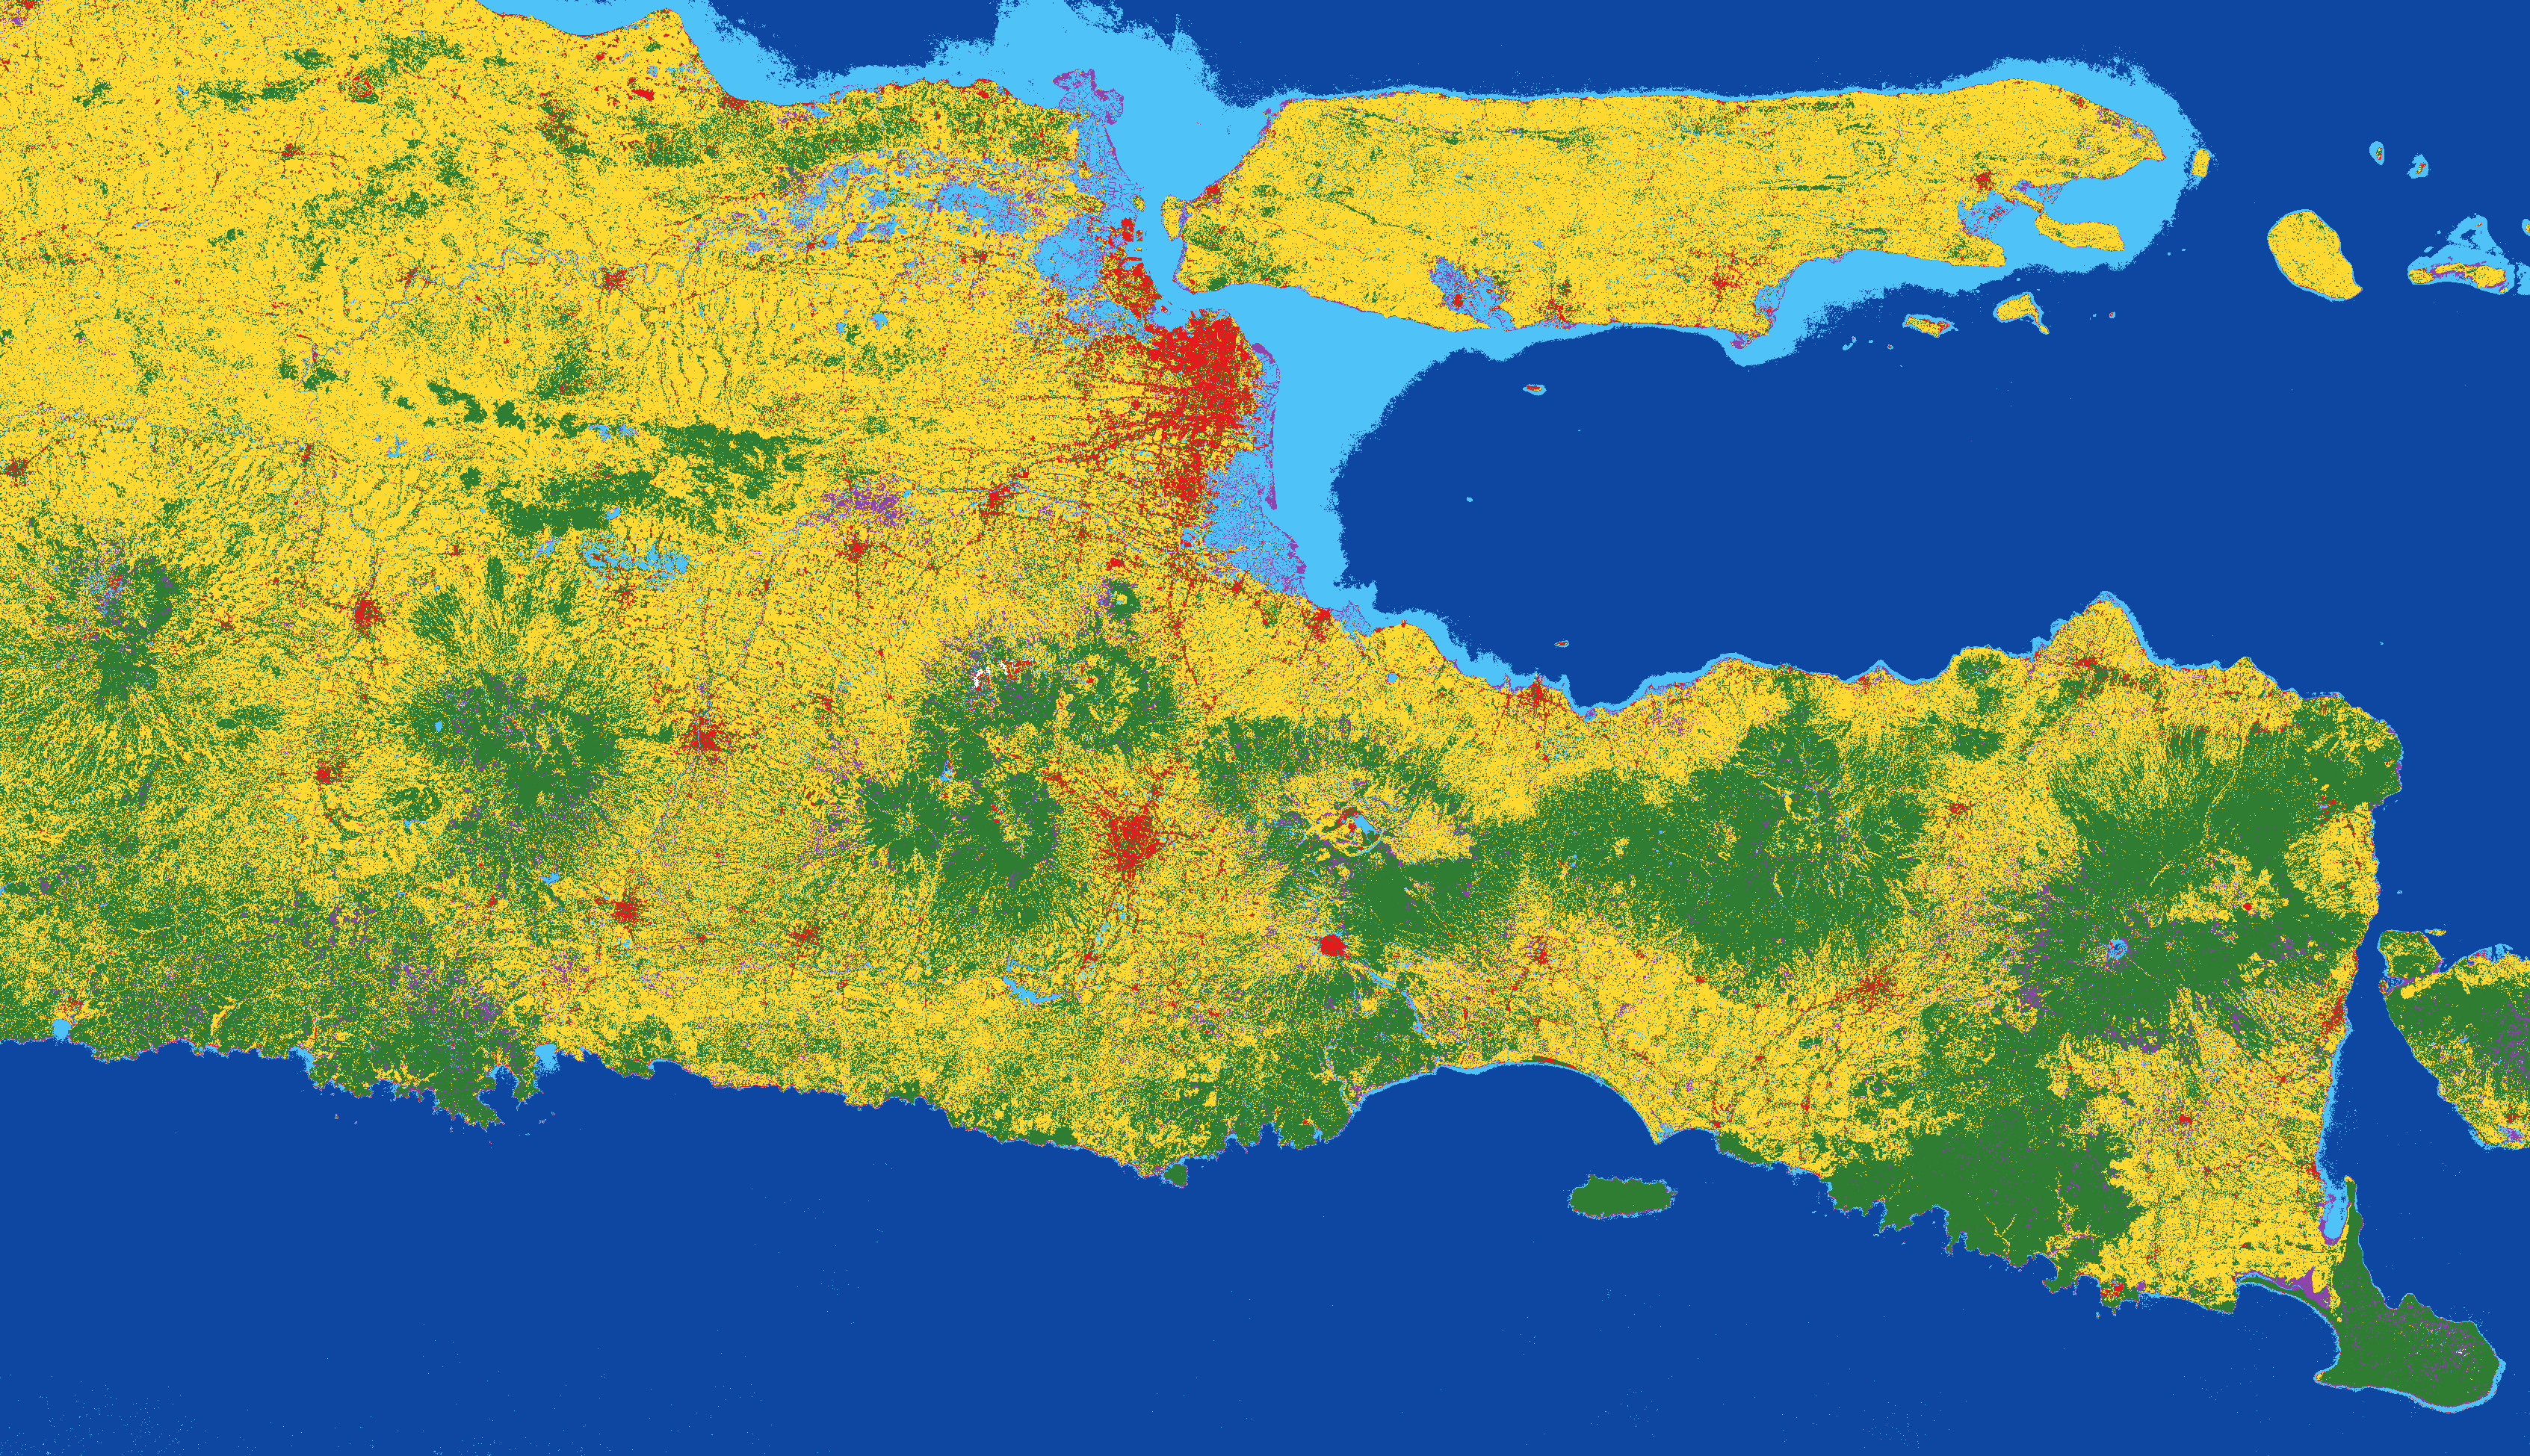

In [20]:
import math, io, requests
import folium
from folium.raster_layers import ImageOverlay
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

# --- Unduh citra satelit Esri untuk AOI, lalu tanam di peta ---
def ambil_satelit(aoi, z=10):
    n = 2 ** z
    def xy(lon, lat):
        x = (lon + 180) / 360 * n
        y = (1 - math.asinh(math.tan(math.radians(lat))) / math.pi) / 2 * n
        return x, y
    def lon_dari_x(x): return x / n * 360 - 180
    def lat_dari_y(y): return math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))

    x0, y0 = xy(aoi[0], aoi[3])
    x1, y1 = xy(aoi[2], aoi[1])
    xa, xb, ya, yb = int(x0), int(x1), int(y0), int(y1)

    mosaik = Image.new("RGB", ((xb - xa + 1) * 256, (yb - ya + 1) * 256), (200, 200, 200))
    url = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"

    def unduh(xy_):
        x, y = xy_
        try:
            r = requests.get(url.format(z=z, x=x, y=y), headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
            return x, y, Image.open(io.BytesIO(r.content)).convert("RGB")
        except Exception:
            return x, y, None

    ubin = [(x, y) for x in range(xa, xb + 1) for y in range(ya, yb + 1)]
    with ThreadPoolExecutor(max_workers=8) as ex:
        for x, y, im in ex.map(unduh, ubin):
            if im is not None:
                mosaik.paste(im, ((x - xa) * 256, (y - ya) * 256))

    batas = [[lat_dari_y(yb + 1), lon_dari_x(xa)], [lat_dari_y(ya), lon_dari_x(xb + 1)]]
    return mosaik, batas

mosaik, batas_satelit = ambil_satelit(AOI, z=10)
mosaik.save("satelit_aoi.jpeg", quality=85)

# --- Peta ---
pusat = [(AOI[1] + AOI[3]) / 2, (AOI[0] + AOI[2]) / 2]
peta = folium.Map(location=pusat, zoom_start=8, tiles=None, control_scale=True)

# Basemap online
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics",
    name="Esri Satellite (online)", max_zoom=19, overlay=False, control=True,
).add_to(peta)
folium.TileLayer(
    tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
    attr="Google Hybrid", name="Google Hybrid (dengan label)",
    max_zoom=20, overlay=False, control=True, show=False,
).add_to(peta)

# LAYER BAWAH: satelit tertanam
ImageOverlay(image="satelit_aoi.jpeg", bounds=batas_satelit, opacity=1,
             name="Satelit (tertanam)", interactive=False, zindex=1).add_to(peta)

# LAYER ATAS: hasil klasifikasi KNN
ImageOverlay(image=rgba, bounds=batas_peta, opacity=0.65,
             name="Hasil Klasifikasi KNN", interactive=False, zindex=5).add_to(peta)

# Titik sampel per kelas (default disembunyikan)
for nama in NAMA_KELAS:
    grup = folium.FeatureGroup(name=f"Sampel: {nama}", show=False)
    for _, r in df[df["kelas"] == nama].iterrows():
        folium.CircleMarker([r.lat, r.lon], radius=4, color="white", weight=1,
                            fill=True, fill_color=WARNA_KELAS[nama], fill_opacity=1,
                            popup=f"{nama} (lon {r.lon:.4f}, lat {r.lat:.4f})").add_to(grup)
    grup.add_to(peta)

# Kotak batas AOI
grup_aoi = folium.FeatureGroup(name="Batas area studi")
folium.Rectangle([[AOI[1], AOI[0]], [AOI[3], AOI[2]]], color="white", weight=1.5,
                 fill=False, dash_array="6").add_to(grup_aoi)
grup_aoi.add_to(peta)

# Legenda LULC
item = "".join(
    f'<div style="margin:2px 0"><span style="display:inline-block;width:14px;height:14px;'
    f'background:{WARNA_KELAS[k]};border:1px solid #333;margin-right:6px;vertical-align:middle"></span>{k}</div>'
    for k in NAMA_KELAS)
legenda = (f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
           f'padding:10px 12px;border:1px solid #888;border-radius:6px;font:13px Arial;">'
           f'<b>Legenda LULC</b><br>{item}</div>')
peta.get_root().html.add_child(folium.Element(legenda))

folium.LayerControl(collapsed=False).add_to(peta)
peta.fit_bounds([[AOI[1], AOI[0]], [AOI[3], AOI[2]]])

peta.save("hasil_klasifikasi_knn.html")
print("Peta disimpan: hasil_klasifikasi_knn.html (dapat ditanam di web statis lewat <iframe>)")
peta

In [21]:
terbaik_rasio = tab_rasio.sort_values("Akurasi rata-rata", ascending=False).iloc[0]
kelas_lemah = (pd.Series(f1_score(y_test, pred_final, labels=NAMA_KELAS, average=None, zero_division=0),
                         index=NAMA_KELAS).sort_values())
display(Markdown(f"""
**Ringkasan hasil**

* **Data:** {len(df)} sampel dari {df['kelas'].nunique()} kelas ({', '.join(f'{k}: {v}' for k, v in jml.items())}).
  Pembagian 80:20 menghasilkan **{len(X_train)} data training** dan **{len(X_test)} data testing**.
* **Fitur:** 10 band Sentinel-2A + 8 indeks spektral (NDVI, NDWI, MNDWI, NDBI, NDRE, EVI, SAVI, BSI).
* **Model:** K-Nearest Neighbors (KNN, k={BEST_K}, weights='{BEST_WEIGHTS}', metric='{BEST_METRIC}') dengan skenario fitur terbaik
  **{FITUR_FINAL_NAMA}**.
* **Kinerja model final (data testing):** akurasi **{AKURASI_FINAL:.2%}**, Kappa **{KAPPA_FINAL:.3f}**,
  F1 macro **{F1_FINAL:.3f}**.
* **Eksperimen rasio split:** rata-rata akurasi tertinggi pada rasio **{terbaik_rasio['Rasio train:test']}**
  ({terbaik_rasio['Akurasi rata-rata']:.2%}).
* **Kelas dengan F1 terendah:** **{kelas_lemah.index[0]}** ({kelas_lemah.iloc[0]:.2f}),
  lihat *confusion matrix* untuk melihat kelas mana yang tertukar.
* **Peta:** hasil klasifikasi ditampilkan pada `hasil_klasifikasi_knn.html` di atas citra Google Satellite.
"""))


**Ringkasan hasil**

* **Data:** 285 sampel dari 6 kelas (Sawah: 50, Bangunan: 50, Mangrove: 50, Lahan Hijau: 50, Perairan Terbuka (Laut): 35, Danau: 50).
  Pembagian 80:20 menghasilkan **228 data training** dan **57 data testing**.
* **Fitur:** 10 band Sentinel-2A + 8 indeks spektral (NDVI, NDWI, MNDWI, NDBI, NDRE, EVI, SAVI, BSI).
* **Model:** K-Nearest Neighbors (KNN, k=5, weights='distance', metric='euclidean') dengan skenario fitur terbaik
  **E. Band + indeks (18 fitur)**.
* **Kinerja model final (data testing):** akurasi **78.95%**, Kappa **0.747**,
  F1 macro **0.784**.
* **Eksperimen rasio split:** rata-rata akurasi tertinggi pada rasio **70:30**
  (84.19%).
* **Kelas dengan F1 terendah:** **Lahan Hijau** (0.50),
  lihat *confusion matrix* untuk melihat kelas mana yang tertukar.
* **Peta:** hasil klasifikasi ditampilkan pada `hasil_klasifikasi_knn.html` di atas citra Google Satellite.
